In [2]:
import pandas as pd
import matplotlib.pyplot as plt

Goal of this notebook is to:
1. Determine if there is a relationship between C-AIOE [(Pizzinelli, 2023)](https://www.elibrary.imf.org/view/journals/001/2023/216/article-A001-en.xml) and the Observed Exposure [(Massenkoff & McCrory, 2026)](https://cdn.sanity.io/files/4zrzovbb/website/2b5bbaf2c1eb81dbf6e6fb813c1a24e35a64d376.pdf)
2. Determine if there is a relationship betwen AIOE and Anthropic Usage Rates. As per the advice of Ms. Angela, we have to make sure that when these are standardized, they are standardized from the same population.

Granularity of the Data
1. It is per job but specifically on the simplified codes so only up until the first six codes
2. n

# 1. Relationship between C-AIOE and the Observed Exposure 

From Pizzenelli's paper, they defined complementarity-adjusted AI occupational exposure (C-AIOE) as a "measure, where the exposure of occupations is mitigated by their potential for complementarity. In this alternative measure, a higher value of exposure more closely corresponds to greater risk of substitution and hence of an adverse labor market effect from AI." The values range from 
It is computed for some job $i$ as:
$${C-AIOE}_i = AIOE_i \times (1 - (\theta_i - \theta_{MIN}))$$
Observed Exposure is defined as a measure defined per job, where of those tasks that LLMs could theoretically speed up, which are actually seeing automated usage in professional settings? The values range from 0 to 1

In [3]:
def simplify_dataframe(df):
    """
        Given a dataframe that has SOC codes that have 8 digits, 
        return a new dataframe that has only 6 digits
    """
    # drop the codes that don't end with .00 (i.e., drop the codes that are too specific)
    is_general = df.Code.apply(lambda code : True if code.endswith('.00') else False)
    df = df[is_general].copy()
    df.Code = df.Code.str[:-3]

    return df

In [11]:
# worldbank
aioe_df = pd.read_json('../data/ai_measurements/soc_raw_aioe.json', typ='series').reset_index()
aioe_df.columns = ['Code', 'AIOE']
aioe_simplified_df  = simplify_dataframe(aioe_df)

comple_df =  pd.read_json('../data/ai_measurements/soc_complementarity.json', typ='series').reset_index()
comple_df.columns = ['Code', 'Complementarity']
comple_df.Complementarity = comple_df.Complementarity / 100
comple_simplified_df  = simplify_dataframe(comple_df)

# anthropic
observed_exposure_df = pd.read_csv('../data/ai_measurements/job_exposure.csv', names=['Code', 'Title', 'Observed Exposure'], header=0)

# combine worldbank and anthropic
worldbank_df = aioe_simplified_df.merge(comple_simplified_df, on='Code').dropna()
worldbank_anthropic_df = worldbank_df.merge(observed_exposure_df, on='Code', how='left')

# # standardize AIOE
#worldbank_anthropic_df['AIOE'] = worldbank_anthropic_df['AIOE'] * 100
#worldbank_anthropic_df['AIOE'] = (worldbank_anthropic_df['AIOE'] - worldbank_anthropic_df['AIOE'].mean())/ worldbank_anthropic_df['AIOE'].std()

# compute for C-AIOE
min_complementarity = worldbank_anthropic_df.Complementarity.min()

worldbank_anthropic_df['C-AIOE'] = (
    worldbank_anthropic_df['AIOE']
    * (1 - (worldbank_anthropic_df['Complementarity'] - min_complementarity))
)

In [5]:
worldbank_anthropic_df.sort_values(by='C-AIOE', ascending=True)

,Code,AIOE,Complementarity,Title,Observed Exposure,C-AIOE
404,33-1021,5.735875,0.819792,First-Line Supervisors of Firefighting and Pre...,0.0000,3.204920
579,47-2022,5.265329,0.756667,Stonemasons,0.0000,3.274377
679,49-9081,5.563133,0.784167,Wind Turbine Service Technicians,0.0000,3.306587
671,49-9051,5.475666,0.772917,Electrical Power-Line Installers and Repairers,0.0000,3.316200
624,47-5012,5.683829,0.791250,"Rotary Drill Operators, Oil and Gas",0.0000,3.338065
...,...,...,...,...,...,...
559,43-9081,6.615592,0.464792,Proofreaders and Copy Markers,0.1781,6.044997
512,43-3011,6.607668,0.460625,Bill and Account Collectors,0.2989,6.065289
555,43-9041,6.521554,0.440000,Insurance Claims and Policy Processing Clerks,0.1467,6.120750
71,13-2082,6.658139,0.453125,Tax Preparers,0.1283,6.161553


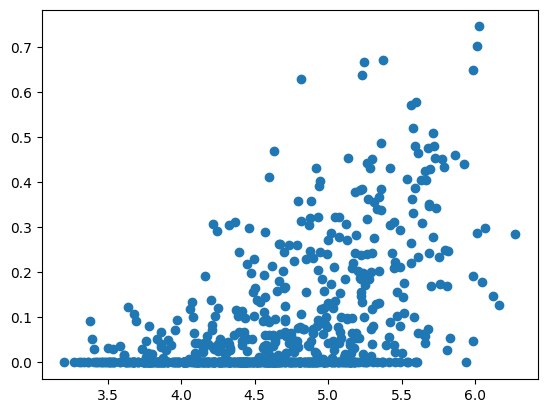

In [12]:
plt.scatter(worldbank_anthropic_df['C-AIOE'], worldbank_anthropic_df['Observed Exposure'])

In [10]:
worldbank_anthropic_df['C-AIOE'].corr(worldbank_anthropic_df['Observed Exposure'])

np.float64(0.5223310651245813)

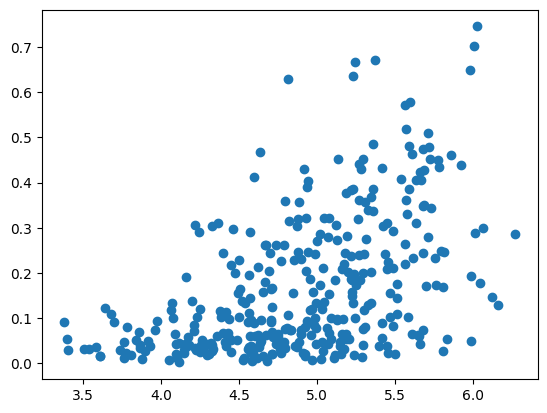

In [7]:
is_observed = worldbank_anthropic_df['Observed Exposure'] > 0
plt.scatter(worldbank_anthropic_df.loc[is_observed, 'C-AIOE'], worldbank_anthropic_df.loc[is_observed, 'Observed Exposure'])

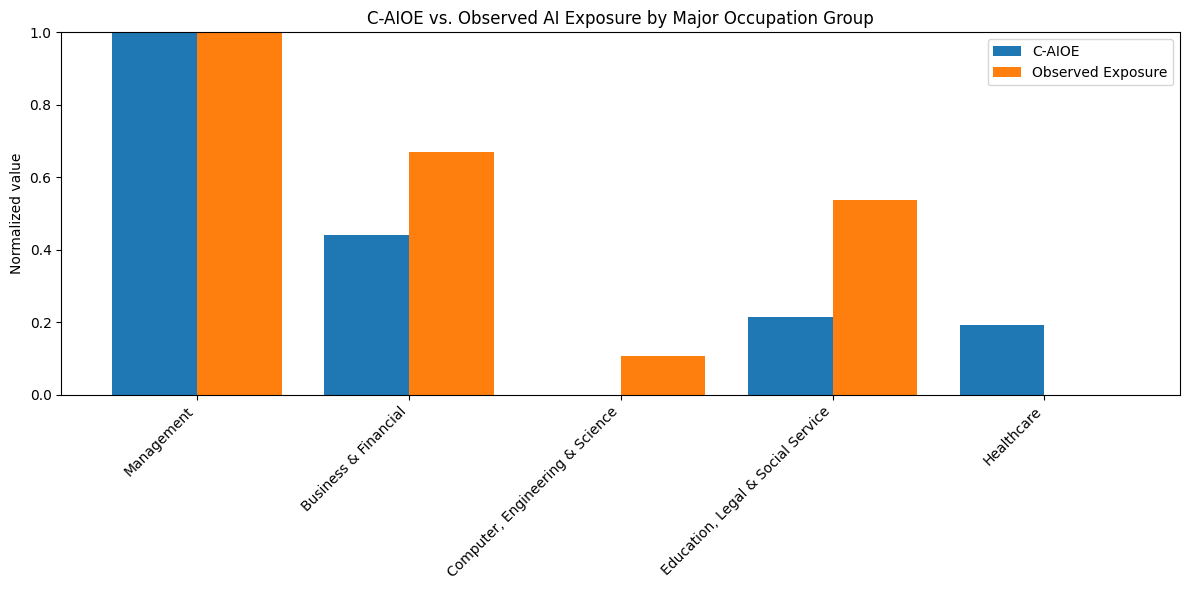

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Major occupation group names
major_groups = {
    '1': 'Management',
    '2': 'Business & Financial',
    '3': 'Computer, Engineering & Science',
    '4': 'Education, Legal & Social Service',
    '5': 'Healthcare',
    '6': 'Service',
    '7': 'Sales & Office',
    '8': 'Natural Resources, Construction & Maintenance',
    '9': 'Production, Transportation & Material Moving',
}

# Get major occupation group from the first SOC digit
df = worldbank_anthropic_df.copy()
df['Major Group'] = df['Code'].str[0]

# Aggregate
grouped = (
    df.groupby('Major Group')[['C-AIOE', 'Observed Exposure']]
    .mean()
    .reindex(major_groups.keys())
).dropna()

grouped.index = grouped.index.map(major_groups)

# Normalize both measures to 0-1
normalized = (grouped - grouped.min()) / (
    grouped.max() - grouped.min()
)

# Plot grouped bars
x = np.arange(len(normalized))
width = 0.4

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    x - width / 2,
    normalized['C-AIOE'],
    width,
    label='C-AIOE'
)

ax.bar(
    x + width / 2,
    normalized['Observed Exposure'],
    width,
    label='Observed Exposure'
)

ax.set_xticks(x)
ax.set_xticklabels(
    normalized.index,
    rotation=45,
    ha='right'
)

ax.set_ylabel('Normalized value')
ax.set_title(
    'C-AIOE vs. Observed AI Exposure by Major Occupation Group'
)

ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.show()

In [15]:
grouped

,C-AIOE,Observed Exposure
Major Group,,
Management,4.971837,0.141752
Business & Financial,4.637685,0.097213
"Computer, Engineering & Science",4.375081,0.021791
"Education, Legal & Social Service",4.502691,0.079426
Healthcare,4.489579,0.007357
Service,NaN,NaN
Sales & Office,NaN,NaN
"Natural Resources, Construction & Maintenance",NaN,NaN
"Production, Transportation & Material Moving",NaN,NaN


In [8]:
# anthropic
anthropic_df = pd.read_csv('../data/ai_measurements/release-2026-06-26/aei_claude_ai_2026-06-26.csv')

# get the rows where it is for the philippines and contains the SOC codes and for the latest month
anthropic_usage_df = anthropic_df.query(
    "category_name == 'soc_occupation' "
    "and metric_id == 'pct' "
    "and geo_level == 'global' "
    "and hierarchy_level == 0 "
    "and date_start == '2026-05-01' "
    "and date_end == '2026-06-01'"
).sort_values(by='value', ascending=False)
anthropic_usage_df = anthropic_usage_df[['node_external_id', 'value']].copy()
anthropic_usage_df.columns = ['Code', 'Usage Rate']
anthropic_usage_simplified_df = simplify_dataframe(anthropic_usage_df)

In [9]:
anthropic_usage_simplified_df

,Code,Usage Rate
981296,25-4022,4.22
923882,41-2021,2.72
1541571,27-3041,2.58
1089063,27-3043,2.22
1487721,15-1232,2.17
...,...,...
1485005,21-1091,0.00
1487314,29-2011,0.00
956572,17-2041,0.00
1494882,53-7081,0.00
